# Introduction 

This scientific computation project builds an interactive visualization of a family of fractals invented by me to disprove a mathematical conjecture during my PhD. We first present the code as it appears in my dissertation. We'll then vectorize this code followed by writing a script that shows how this fractal evolves by varying a parameter. Lastly, we'll deploy this code to Streamlit to visualize these fractals evolving in real time.  

**Fractal**: For our purpose, a fractal is simply a shape with intricate geometry that "looks" the same upon zooming into the shape. 

Here an abridged version of my dissertation: [Short Dissertation](https://scholarspace.manoa.hawaii.edu/server/api/core/bitstreams/31ac5794-df3a-4efa-b2cf-27ec43a9976a/content).


## Motivation: Koch Snowflake

The main motivation is Helge von Koch's famous [snowflake curve](https://en.wikipedia.org/wiki/Koch_snowflake). It is constructed as follows. Start with an equilateral triangle of unit side-length. Replace the middle thirds of each segment of the triangle by the other two sides of the outward pointing equilateral triangle of side length 1/3. Iterate this process on every resulting segment. The object resulting as a culmination of this process is called Koch's snowflake. Here's a picture of the first step of the process taken from Wikipedia: 
<div style="text-align: center;">
  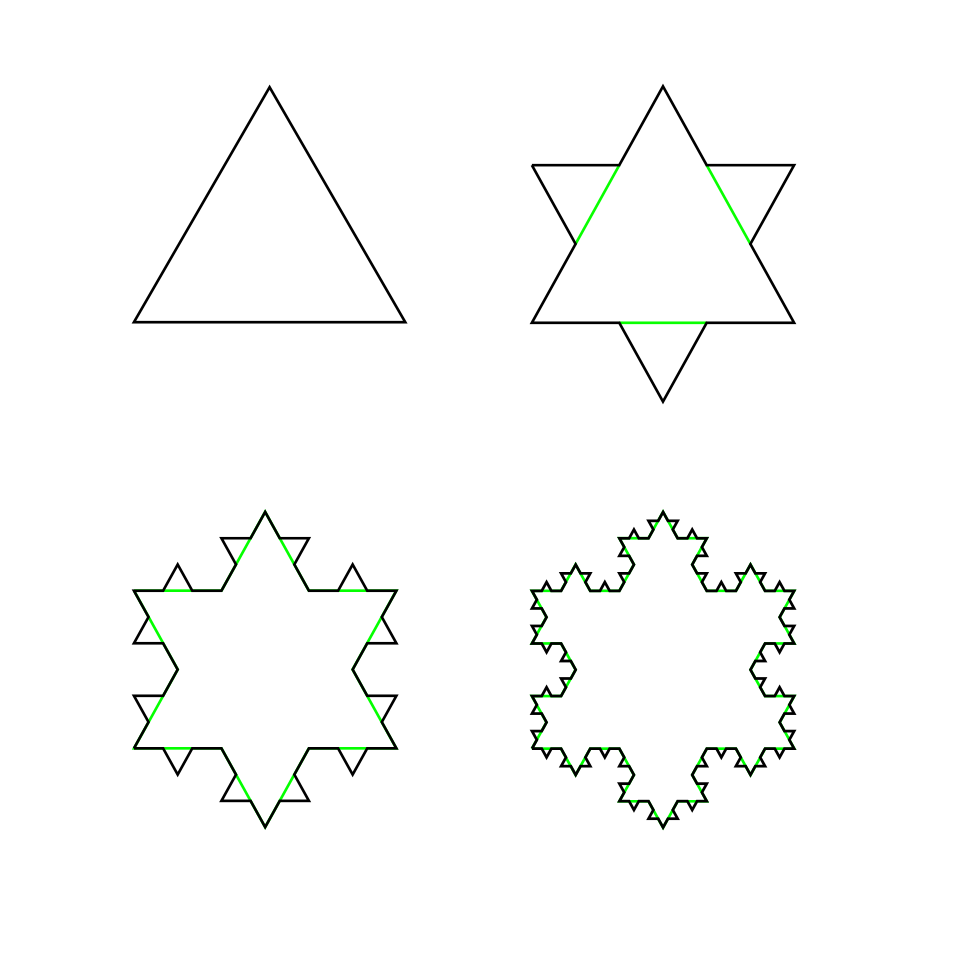
</div>

## Modified Snowflakes

We will modify this construction to obtain an infinite family of such curves. Fix a number $a$ satisfying $1/4<a<1/3$.  Consider the segment $[0,1]$ on the x-axis; this is the zeroth generation of the curve. Remove the middle open interval of length $a$ and replace it by the other two sides of the equilateral triangle of side length $a$. This is the first generation of the process. In the second step, replace the middle interval of length $a^2$ from each edge of the first generation curve with the other two sides of the equilateral triangle of side length $a^2$. At the $k^\text{th}$ generation, remove the middle interval of length $a^k$ from each of the $4^{k-1}$ edges of the previous generation and replace them by the other two sides of the equilateral triangle of length $a^k$. The limit of this process yields a fractal curve that we informally term "modified snowflake".

We begin by implementing this recursive logic using a simple for loop. 

In [45]:
# Function to generate a modified snowflake curve.

# Parameters:
#    points: The starting segment. i.e., the zeroth generation of the fractal. 
#    k: The starting step counter. Always = 1. Cannot be initialized inside the function body since the function calls itself within its body.
#    max_gen: number of iterations we wish to perform.
#    a: A fixed number between 1/4 and 1/3 that determines the shape of the fractal. 

import matplotlib.pyplot as plt
import numpy as np

def generate_modified_koch(points, k, max_gen,a):
    # Stop recursion when max generation is reached.
    if k > max_gen:
        return points
        
    new_points = []

    # Compute base length for current generation k.
    r = (a) ** k  

    # Process each segment sequentially.
    for i in range(len(points) - 1):
        A = np.array(points[i])
        B = np.array(points[i + 1])
        AB = B - A
        L = np.linalg.norm(AB)

        # Determine unit direction and perpendicular normal vector.
        unit_AB = AB / L
        normal = np.array([-unit_AB[1], unit_AB[0]])  

        # Calculate base length of new triangles and margins along current segment.
        base_length = r 
        margin = (L - base_length) / 2

        # Locate base end-points P1 and P2, and midpoint M.
        P1 = A + unit_AB * margin          
        P2 = A + unit_AB * (margin + base_length)  
        M = (P1 + P2) / 2                   

        # Calculate the peak vertex of the new triangle.
        height = (np.sqrt(3) / 2) * base_length
        P3 = M + normal * height        

        # Append transformed sequence of 4 points replacing segment AB
        new_points += [tuple(A), tuple(P1), tuple(P3), tuple(P2)]

    # Re-attach final endpoint to complete the segment.
    new_points.append(tuple(points[-1]))  

    # Iterate/recurse to next generation with updated point list.
    return generate_modified_koch(new_points, k + 1, max_gen,a)

Let's visualize such a modified snowflake curve. 

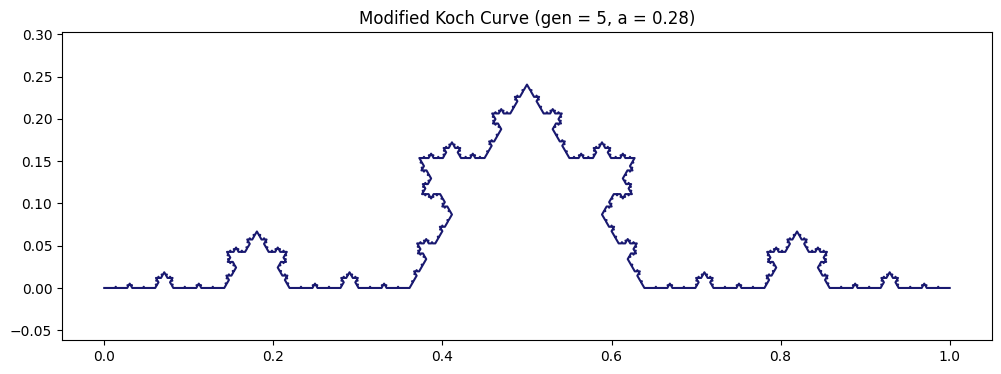

In [67]:
start = (0, 0)
end = (1, 0)
initial_points = [start, end]
max_gen = 5
a = 1/3.6
curve = generate_modified_koch(initial_points, 1, max_gen, a)

x, y = zip(*curve)
plt.figure(figsize=(12, 4))
plt.plot(x, y, color='midnightblue')
plt.axis('equal')
plt.title(f"Modified Koch Curve (gen = {gen}, a = {a:.2f})")
plt.show()

To compare, let's visualize the standard Koch snowflake curve. This is our modified snowflake when $a=1/3$.

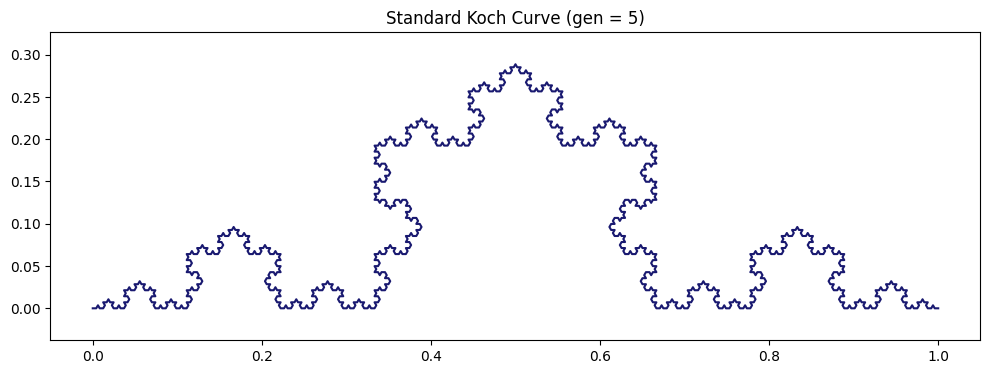

In [47]:
start = (0, 0)
end = (1, 0)
initial_points = [start, end]
max_gen = 5
a = 1/3
curve = generate_modified_koch(initial_points, 1, max_gen, a)

x, y = zip(*curve)
plt.figure(figsize=(12, 4))
plt.plot(x, y, color='midnightblue')
plt.axis('equal')
plt.title(f"Standard Koch Curve (gen = {gen})")
plt.show()

As you can see, they look similar, but the modified snowflake is relatively more "pointy". But wait! This does not look like a closed curve. To obtain the true snowflake (a closed curve), we concatenate three copies of this curve "living" on the segment $[0,1]$ to obtain a closed curve.  

## Construct Modified Snowflakes

In [48]:
# Generates a closed modified snowflake by placing three modified Koch curves along the sides of an equilateral triangle.

def modified_snowflake(max_gen, a, side_length):

# Parameters:
#    max_gen: Number of iterations to perform.
#    a: Fixed number between 1/4 and 1/3 determining shape/scaling.
#    side_length: Length of the base equilateral triangle sides.

    # Define the 3 vertices of an equilateral triangle.
    p1 = (0.0, 0.0)
    p2 = (side_length, 0.0)
    p3 = (side_length / 2.0, (np.sqrt(3) / 2.0) * side_length)

    # Define the initial closed loop (0th generation).
    initial_triangle = [p1, p3, p2, p1]

    # Generate the fractal curve across all 3 sides simultaneously
    snowflake = generate_modified_koch(initial_triangle, k = 1, max_gen = max_gen, a = a)

    return snowflake

Let's visualize one of these true modified snowflakes and compare it to the standard Koch snowflake. 

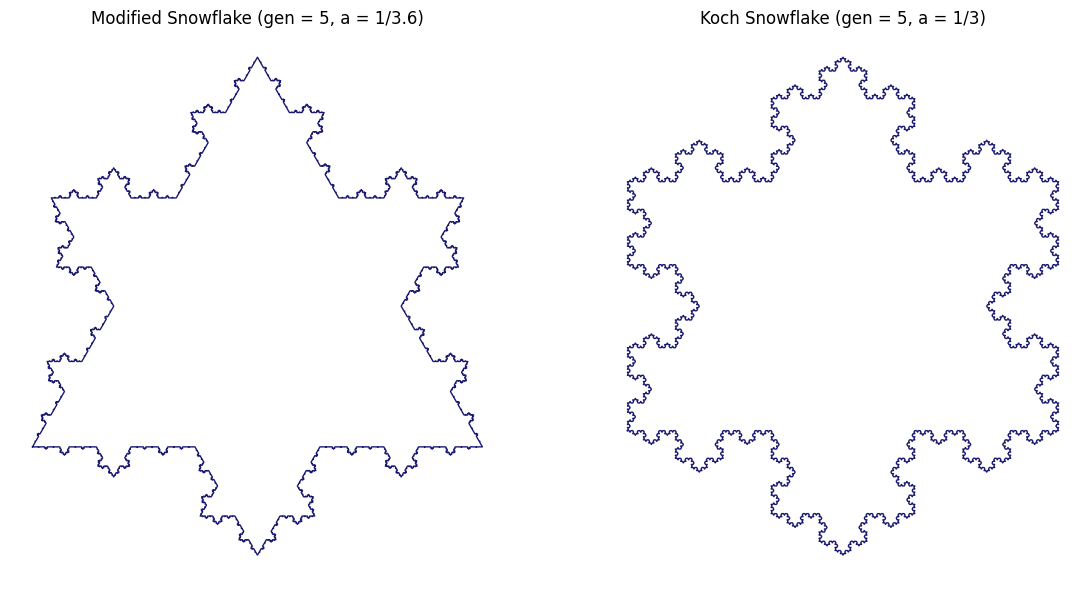

In [68]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Plot 1: a = 1/3.6 ---
snowflake1 = modified_snowflake(max_gen=5, a=1/3.6, side_length=1)
x1, y1 = zip(*snowflake1)

axes[0].plot(x1, y1, color="midnightblue", linewidth=1.0)
axes[0].set_aspect("equal")
axes[0].axis("off")
axes[0].set_title("Modified Snowflake (gen = 5, a = 1/3.6)", fontsize=12)

# --- Plot 2: a = 1/3 ---
snowflake2 = modified_snowflake(max_gen=5, a=1/3, side_length=1)
x2, y2 = zip(*snowflake2)

axes[1].plot(x2, y2, color="midnightblue", linewidth=1.0)
axes[1].set_aspect("equal")
axes[1].axis("off")
axes[1].set_title("Koch Snowflake (gen = 5, a = 1/3)", fontsize=12)

# Adjust layout to remove extra whitespace between plots
plt.tight_layout()
plt.show()